# ASR Statistics Plots

This notebook compares ASR models with a WER-first policy for cross-model comparison.


Cross-model error per clip $i$ and model $m$ uses WER:

$$
\text{error}^{\text{cross}}_{i,m}=\text{WER}_{i,m}
$$

Condition mean WER (for SNR/OVR plots):

$$
\overline{\text{WER}}_{m,c}=\frac{1}{N_{m,c}}\sum_{i\in c}\text{WER}_{i,m}
$$

Exception: the faster-whisper vs whisperx pairwise scatter uses ORC-WER only.

Average inference time per sample and RTF are also reported, where:

$$
t^{\text{per-sample}}_m=\frac{\text{total processing time}_m}{\text{sample count}_m}
$$

$$
\text{RTF}_m=\frac{\text{total audio duration}_m}{\text{total processing time}_m}
$$

In [18]:
result_df

NameError: name 'result_df' is not defined

In [14]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "WER_Results_by_Model").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "WER_Results_by_Model"
MANIFEST_PATH = PROJECT_ROOT / "Output" / "manifest.csv"

# Resolve timings path robustly (root first, then common fallback under Code/).
_timings_candidates = [
    PROJECT_ROOT / "timings_100_random.json",
    PROJECT_ROOT / "Code" / "timings_100_random.json",
    Path.cwd() / "timings_100_random.json",
]
TIMINGS_PATH = next((path for path in _timings_candidates if path.exists()), _timings_candidates[0])

PLOTS_DIR = PROJECT_ROOT / "Output" / "plot"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PAIRWISE_ORC_WER_MODELS = ["faster-whisper", "whisperx"]
MODEL_ORDER = ["faster-whisper", "whisperx", "parakeet", "wav2vec2"]
MODEL_COLORS = {
    "faster-whisper": "#1f77b4",
    "whisperx": "#ff7f0e",
    "parakeet": "#2ca02c",
    "wav2vec2": "#d62728",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Plots dir: {PLOTS_DIR}")
print(f"Timings file: {TIMINGS_PATH}")

Project root: /home/jamin/Year3Proj
Results dir: /home/jamin/Year3Proj/WER_Results_by_Model
Plots dir: /home/jamin/Year3Proj/Output/plot
Timings file: /home/jamin/Year3Proj/timings_100_random.json


In [ ]:
def load_model_results(results_dir: Path = RESULTS_DIR) -> pd.DataFrame:
    rows = []
    for result_path in sorted(results_dir.glob("*_wer_results.json")):
        with open(result_path, "r", encoding="utf-8") as handle:
            payload = json.load(handle)
        model = payload.get("model", result_path.stem.replace("_wer_results", ""))
        for item in payload.get("results", []):
            metrics = item.get("metrics", {}) if item.get("status") == "success" else {}
            row = {
                "model": model,
                "clip_id": item.get("clip_id"),
                "status": item.get("status"),
                "metric_type": item.get("metric_type"),
                "wer_method": item.get("wer_method", np.nan),
                "wer": metrics.get("wer", np.nan),
                "mrs_wer": metrics.get("mrs_wer", np.nan),
                "orc_wer": metrics.get("orc_wer", np.nan),
            }
            rows.append(row)
    return pd.DataFrame(rows)


def _format_snr_label(value) -> str:
    if pd.isna(value):
        return "clean"
    numeric = pd.to_numeric(value, errors="coerce")
    if pd.isna(numeric):
        return str(value)
    return f"{float(numeric):g}"


def load_manifest(manifest_path: Path = MANIFEST_PATH) -> pd.DataFrame:
    manifest = pd.read_csv(manifest_path)
    keep_cols = [col for col in ["clip_id", "overlap_ratio_target", "overlap_ratio_actual", "snr_db", "noise_type"] if col in manifest.columns]
    manifest = manifest[keep_cols].copy()
    if "snr_db" in manifest.columns:
        manifest["snr_label"] = manifest["snr_db"].apply(_format_snr_label)
    if "overlap_ratio_target" in manifest.columns:
        manifest["ovr_label"] = manifest["overlap_ratio_target"].map(lambda value: f"{float(value):.2f}" if pd.notna(value) else "unknown")
    return manifest


def load_timings(timings_path: Path = TIMINGS_PATH) -> pd.DataFrame:
    if timings_path is None or not Path(timings_path).exists():
        return pd.DataFrame(columns=["model", "duration_sec", "item_count", "sec_per_item", "rtf", "batch_key"])

    with open(timings_path, "r", encoding="utf-8") as handle:
        timings_payload = json.load(handle)

    rows = []

    # New schema: top-level metadata + `results` list with one row per model.
    if isinstance(timings_payload, dict) and isinstance(timings_payload.get("results"), list):
        sample_size = timings_payload.get("sample_size")
        seed = timings_payload.get("seed")
        total_audio_duration_sec = pd.to_numeric(timings_payload.get("total_audio_duration_sec"), errors="coerce")

        for result in timings_payload["results"]:
            model_name = result.get("model")
            sample_count = pd.to_numeric(result.get("sample_count"), errors="coerce")
            duration_sec = pd.to_numeric(result.get("duration_sec"), errors="coerce")
            per_sample_sec = pd.to_numeric(result.get("processing_time_per_sample_sec"), errors="coerce")
            if pd.isna(per_sample_sec):
                per_sample_sec = pd.to_numeric(result.get("sec_per_audio"), errors="coerce")

            rtf = pd.to_numeric(result.get("rtf"), errors="coerce")
            if pd.isna(rtf):
                rtf = pd.to_numeric(result.get("rtfx"), errors="coerce")
            if pd.isna(rtf) and pd.notna(total_audio_duration_sec) and total_audio_duration_sec > 0 and pd.notna(duration_sec) and duration_sec > 0:
                rtf = float(total_audio_duration_sec) / float(duration_sec)

            if not model_name or pd.isna(sample_count) or sample_count <= 0 or pd.isna(duration_sec):
                continue

            rows.append(
                {
                    "model": model_name,
                    "duration_sec": float(duration_sec),
                    "item_count": int(sample_count),
                    "sec_per_item": float(per_sample_sec) if pd.notna(per_sample_sec) else float(duration_sec) / float(sample_count),
                    "rtf": float(rtf) if pd.notna(rtf) else np.nan,
                    "batch_key": f"sample_{sample_size}_seed_{seed}_{model_name}",
                }
            )

    # Legacy schema fallback: flat dict of batch_key -> duration_sec.
    elif isinstance(timings_payload, dict):
        model_prefixes = {
            "faster-whisper": "faster_whisper",
            "wav2vec2": "wav2vec2",
            "parakeet": "parakeet",
            "whisperx": "whisperx",
        }
        for key, duration in timings_payload.items():
            for model_name, prefix in model_prefixes.items():
                if key.startswith(f"transcribe_{prefix}_"):
                    suffix = key.replace(f"transcribe_{prefix}_", "", 1)
                    parts = [chunk for chunk in suffix.split("_-") if chunk]
                    item_count = len(parts)
                    if item_count == 0:
                        continue
                    rows.append(
                        {
                            "model": model_name,
                            "duration_sec": float(duration),
                            "item_count": item_count,
                            "sec_per_item": float(duration) / float(item_count),
                            "rtf": np.nan,
                            "batch_key": key,
                        }
                    )
                    break

    return pd.DataFrame(rows)


CROSS_MODEL_CLIP_REGEX = r"(^mix_[0-9]+_0\.(00|14|20|40)_2_7\.4_T$)|(^mix_[0-9]+_0\.14_2_(None|7\.4|0|-5)_T$)"


results_df = load_model_results()
manifest_df = load_manifest()
timings_df = load_timings()

results_df = results_df[results_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
manifest_df = manifest_df[manifest_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()

status_summary_df = (
    results_df.groupby(["model", "status"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)

results_df = results_df.merge(manifest_df, on="clip_id", how="left")

# Cross-model metric policy: use WER for all cross-model comparisons.
results_df["cross_metric_name"] = "WER"
results_df["cross_model_error"] = results_df["wer"]
results_df["cross_model_error_clipped"] = results_df["cross_model_error"].clip(upper=1.0)
results_df["wer_minus_mrs_wer"] = results_df["wer"] - results_df["mrs_wer"]

successful_df = results_df[results_df["status"] == "success"].copy()
successful_df = successful_df[pd.notna(successful_df["cross_model_error"])].copy()

summary_df = (
    successful_df.groupby("model")
    .agg(
        clips=("clip_id", "count"),
        mean_error=("cross_model_error", "mean"),
        median_error=("cross_model_error", "median"),
        mean_error_clipped=("cross_model_error_clipped", "mean"),
        pct_error_gt_1=("cross_model_error", lambda s: 100.0 * (s > 1).mean()),
    )
    .reset_index()
)

metric_breakdown_df = (
    successful_df.groupby(["model", "cross_metric_name"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)

method_summary_df = (
    successful_df.dropna(subset=["wer_method"])
    .groupby(["model", "wer_method"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)

three_metric_table_df = (
    successful_df.groupby("model", as_index=False)
    .agg(
        clips=("clip_id", "count"),
        wer_mean=("wer", "mean"),
        mrs_wer_mean=("mrs_wer", "mean"),
        orc_wer_mean=("orc_wer", "mean"),
        wer_minus_mrs_wer_mean=("wer_minus_mrs_wer", "mean"),
        wer_minus_mrs_wer_median=("wer_minus_mrs_wer", "median"),
        wer_minus_mrs_wer_abs_mean=("wer_minus_mrs_wer", lambda s: np.nanmean(np.abs(s))),
    )
)

print(f"Loaded {len(results_df)} filtered clip results across {results_df['model'].nunique()} models")
print("\nStatus counts after regex filter:")
print(status_summary_df.sort_values(["model", "status"]))
print("\nPer-model cross-metric error summary (WER):")
print(summary_df)
print("\nCross-metric policy by model:")
print(metric_breakdown_df.sort_values(["model", "cross_metric_name"]))
print("\nPer-model table of WER, MRS-WER, ORC-WER, and WER-MRS-WER difference:")
print(three_metric_table_df.sort_values("model"))
if not method_summary_df.empty:
    print("\nWER method usage by model:")
    print(method_summary_df)

missing_success_models = [
    model for model in MODEL_ORDER
    if model in set(results_df["model"]) and model not in set(successful_df["model"])
]
if missing_success_models:
    print("\nWarning: models with zero successful rows in filtered subset:")
    for model in missing_success_models:
        print(f"- {model}")

Loaded 2800 filtered clip results across 4 models

Status counts after regex filter:
            model   status  clips
0  faster-whisper  success    700
1        parakeet  success    700
2        wav2vec2  success    700
3        whisperx  success    700

Per-model cross-metric error summary (WER):
            model  clips  mean_error  median_error  mean_error_clipped  \
0  faster-whisper    700    0.158692      0.122549            0.158645   
1        parakeet    700    0.503479      0.524857            0.503479   
2        wav2vec2    700    0.228130      0.205064            0.228130   
3        whisperx    700    0.181304      0.138595            0.181304   

   pct_error_gt_1  
0        0.142857  
1        0.000000  
2        0.000000  
3        0.000000  

Cross-metric policy by model:
            model cross_metric_name  clips
0  faster-whisper               WER    700
1        parakeet               WER    700
2        wav2vec2               WER    700
3        whisperx         

: 

In [ ]:
# Compare MRS_WER vs WER separately for no-overlap and overlap clips.
overlap_col = "overlap_ratio_target" if "overlap_ratio_target" in results_df.columns else "overlap_ratio_actual"
if overlap_col not in results_df.columns:
    print("No overlap column found in results_df (expected overlap_ratio_target or overlap_ratio_actual).")
else:
    wer_mrs_df = results_df[
        (results_df["status"] == "success")
        & pd.notna(results_df["wer"])
        & pd.notna(results_df["mrs_wer"])
    ].copy()

    overlap_values = pd.to_numeric(wer_mrs_df[overlap_col], errors="coerce").fillna(0.0)
    wer_mrs_df["overlap_group"] = np.where(np.isclose(overlap_values, 0.0), "no_overlap", "overlap")
    wer_mrs_df["wer_minus_mrs_wer"] = wer_mrs_df["wer"] - wer_mrs_df["mrs_wer"]
    wer_mrs_df["abs_diff"] = wer_mrs_df["wer_minus_mrs_wer"].abs()

    comparison_summary_df = (
        wer_mrs_df.groupby(["model", "overlap_group"], as_index=False)
        .agg(
            clips=("clip_id", "count"),
            wer_mean=("wer", "mean"),
            mrs_wer_mean=("mrs_wer", "mean"),
            diff_mean=("wer_minus_mrs_wer", "mean"),
            diff_median=("wer_minus_mrs_wer", "median"),
            abs_diff_mean=("abs_diff", "mean"),
            pct_wer_gt_mrs=("wer_minus_mrs_wer", lambda s: 100.0 * (s > 0).mean()),
            pct_wer_lt_mrs=("wer_minus_mrs_wer", lambda s: 100.0 * (s < 0).mean()),
            pct_wer_eq_mrs=("wer_minus_mrs_wer", lambda s: 100.0 * np.isclose(s, 0.0).mean()),
        )
        .sort_values(["model", "overlap_group"])
    )

    print("WER vs MRS_WER comparison split by overlap group:")
    display(comparison_summary_df.round(4))

    comparison_pivot_df = comparison_summary_df.pivot(
        index="model", columns="overlap_group", values=["wer_mean", "mrs_wer_mean", "diff_mean", "abs_diff_mean"]
    )
    print("Compact pivot view (model x overlap_group):")
    display(comparison_pivot_df.round(4))

WER vs MRS_WER comparison split by overlap group:


,model,overlap_group,clips,wer_mean,mrs_wer_mean,diff_mean,diff_median,abs_diff_mean,pct_wer_gt_mrs,pct_wer_lt_mrs,pct_wer_eq_mrs
0,faster-whisper,no_overlap,100,0.0519,0.0608,-0.0089,0.0000,0.0091,2.0000,17.0000,81.0000
1,faster-whisper,overlap,600,0.1765,0.1716,0.0049,0.0000,0.0134,35.8333,17.6667,46.5000
2,parakeet,no_overlap,100,0.3068,0.3162,-0.0094,0.0000,0.0100,4.0000,24.0000,72.0000
3,parakeet,overlap,600,0.5363,0.5478,-0.0116,0.0000,0.0204,27.6667,31.3333,41.0000
4,wav2vec2,no_overlap,100,0.0397,0.0413,-0.0015,0.0000,0.0015,0.0000,13.0000,87.0000
5,wav2vec2,overlap,600,0.2595,0.2395,0.0201,0.0113,0.0219,79.3333,7.1667,13.5000
6,whisperx,no_overlap,100,0.0382,0.0390,-0.0007,0.0000,0.0007,0.0000,7.0000,93.0000
7,whisperx,overlap,600,0.2052,0.2021,0.0030,0.0000,0.0086,25.3333,13.8333,60.8333


Compact pivot view (model x overlap_group):


wer_mean         mrs_wer_mean          diff_mean          \
overlap_group  no_overlap overlap   no_overlap overlap no_overlap overlap   
model                                                                       
faster-whisper     0.0519  0.1765       0.0608  0.1716    -0.0089  0.0049   
parakeet           0.3068  0.5363       0.3162  0.5478    -0.0094 -0.0116   
wav2vec2           0.0397  0.2595       0.0413  0.2395    -0.0015  0.0201   
whisperx           0.0382  0.2052       0.0390  0.2021    -0.0007  0.0030   

               abs_diff_mean          
overlap_group     no_overlap overlap  
model                                 
faster-whisper        0.0091  0.0134  
parakeet              0.0100  0.0204  
wav2vec2              0.0015  0.0219  
whisperx              0.0007  0.0086

: 

In [ ]:
# Top-3 worst performing files per model (using stats_utils helpers).
import sys

code_dir = PROJECT_ROOT / "Code"
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

from stats_utils import load_wer_json, build_analysis_df

worst_rows = []
for result_path in sorted(RESULTS_DIR.glob("*_wer_results.json")):
    payload = load_wer_json(str(result_path))
    model_name = payload.get("model", result_path.stem.replace("_wer_results", ""))

    analysis_df = build_analysis_df(payload, include_failed=False)
    analysis_df = analysis_df[
        analysis_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)
    ].copy()
    if analysis_df.empty:
        continue

    if "model_name" in analysis_df.columns and analysis_df["model_name"].notna().any():
        model_name = analysis_df["model_name"].dropna().iloc[0]

    top3 = (
        analysis_df
        .dropna(subset=["error_value", "clip_id"])
        .sort_values("error_value", ascending=False)
        .head(3)
        .copy()
    )
    if top3.empty:
        continue

    top3["model"] = model_name
    worst_rows.append(
        top3[[
            "model",
            "clip_id",
            "metric_type",
            "error_value",
            "snr_db",
            "overlap_ratio",
            "noise_type",
        ]]
    )

if worst_rows:
    worst_per_model = pd.concat(worst_rows, ignore_index=True)
    worst_per_model = worst_per_model.sort_values(
        ["model", "error_value"], ascending=[True, False]
    ).reset_index(drop=True)

    # Display-friendly SNR label: NaN/None means no-noise condition.
    worst_per_model_display = worst_per_model.copy()
    worst_per_model_display["snr_db"] = worst_per_model_display["snr_db"].apply(
        lambda v: "no noise" if pd.isna(v) else f"{float(v):g}"
    )

    print("Top-3 worst performing files per model (higher error is worse):")
    display(worst_per_model_display)
else:
    print("No successful rows with error values were found after applying CROSS_MODEL_CLIP_REGEX.")

Top-3 worst performing files per model (higher error is worse):


,model,clip_id,metric_type,error_value,snr_db,overlap_ratio,noise_type
0,faster-whisper,mix_0003509_0.20_2_7.4_T,orc_wer,0.952830,7.4,0.20,T
1,faster-whisper,mix_0002057_0.14_2_7.4_T,orc_wer,0.952381,7.4,0.14,T
2,faster-whisper,mix_0001838_0.14_2_None_T,orc_wer,0.950000,no noise,0.14,T
3,parakeet,mix_0001406_0.14_2_None_T,orc_wer,1.000000,no noise,0.14,T
4,parakeet,mix_0001358_0.14_2_None_T,orc_wer,1.000000,no noise,0.14,T
5,parakeet,mix_0001640_0.14_2_0_T,orc_wer,0.974747,0,0.14,T
6,wav2vec2,mix_0004121_0.40_2_7.4_T,orc_wer,0.875676,7.4,0.40,T
7,wav2vec2,mix_0001775_0.14_2_-5_T,orc_wer,0.875000,-5,0.14,T
8,wav2vec2,mix_0002981_0.20_2_7.4_T,orc_wer,0.860465,7.4,0.20,T
9,whisperx,mix_0003917_0.40_2_7.4_T,orc_wer,0.870079,7.4,0.40,T


: 

In [ ]:
# Inspect top-3 worst files per model using ref from manifest.csv and hyp from ASR_transcriptions.json.
import ast
import textwrap
from pathlib import Path
from IPython.display import Markdown, display

def _normalize_ws(text):
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()

def _manifest_transcript_to_text(raw_value):
    text = _normalize_ws(raw_value)
    if not text:
        return ""
    try:
        parsed = ast.literal_eval(text)
    except Exception:
        return text

    pieces = []
    if isinstance(parsed, list):
        for item in parsed:
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                pieces.append(_normalize_ws(item[1]))
            else:
                pieces.append(_normalize_ws(item))
    else:
        pieces.append(_normalize_ws(parsed))
    return " ".join([p for p in pieces if p])

def _hyp_transcript_to_text(raw_value):
    pieces = []
    if isinstance(raw_value, list):
        for item in raw_value:
            if isinstance(item, (list, tuple)) and len(item) >= 2:
                pieces.append(_normalize_ws(item[1]))
            elif isinstance(item, dict):
                pieces.append(_normalize_ws(item.get("text") or item.get("transcript")))
            else:
                pieces.append(_normalize_ws(item))
    elif raw_value is not None:
        pieces.append(_normalize_ws(raw_value))
    return " ".join([p for p in pieces if p])

def _wrap(text, width=120):
    txt = text or ""
    if not txt:
        return "[empty]"
    return "\n".join(textwrap.wrap(txt, width=width, break_long_words=False))

if "worst_per_model" not in globals() or worst_per_model.empty:
    print("Run Cell 4 first to generate worst_per_model.")
else:
    manifest_path = PROJECT_ROOT / "Output" / "manifest.csv"
    hyp_path = PROJECT_ROOT / "ASR_transcriptions.json"

    manifest_lookup = {}
    manifest_raw = pd.read_csv(manifest_path, usecols=["clip_id", "transcript"])

    for _, r in manifest_raw.iterrows():
        manifest_lookup[r["clip_id"]] = _manifest_transcript_to_text(r["transcript"])

    with open(hyp_path, "r", encoding="utf-8") as handle:
        hyp_payload = json.load(handle)

    compare_rows = []
    for _, row in worst_per_model.iterrows():
        clip_id = row["clip_id"]
        model_name = row["model"]

        ref_text = manifest_lookup.get(clip_id, "")

        clip_bundle = hyp_payload.get(clip_id, {}) if isinstance(hyp_payload, dict) else {}
        transcript_map = clip_bundle.get("transcript", {}) if isinstance(clip_bundle, dict) else {}
        hyp_raw = transcript_map.get(model_name) if isinstance(transcript_map, dict) else None
        hyp_text = _hyp_transcript_to_text(hyp_raw)

        compare_rows.append(
            {
                "model": model_name,
                "clip_id": clip_id,
                "metric_type": row.get("metric_type"),
                "error_value": row.get("error_value"),
                "ref_text": ref_text or "[not found in manifest]",
                "hyp_text": hyp_text or "[not found in ASR_transcriptions]",
            }
        )

    compare_df = pd.DataFrame(compare_rows)
    compare_df = compare_df.sort_values(["model", "error_value"], ascending=[True, False]).reset_index(drop=True)

    print("Readable transcript comparison for top-3 worst files per model:")
    for model_name, group in compare_df.groupby("model", sort=True):
        display(Markdown(f"## {model_name}"))
        for rank, (_, r) in enumerate(group.iterrows(), start=1):
            block = [
                f"### {rank}. {r['clip_id']}",
                f"- metric: {r['metric_type']}",
                f"- error: {float(r['error_value']):.4f}",
                "",
                "**Reference (manifest.csv):**",
                "```text",
                _wrap(r["ref_text"]),
                "```",
                "",
                "**Hypothesis (ASR_transcriptions.json):**",
                "```text",
                _wrap(r["hyp_text"]),
                "```",
            ]
            display(Markdown("\n".join(block)))

    # Keep structured table available for downstream analysis if needed.
    pd.set_option("display.max_colwidth", 220)

Readable transcript comparison for top-3 worst files per model:


## faster-whisper

### 1. mix_0003509_0.20_2_7.4_T
- metric: orc_wer
- error: 0.9528

**Reference (manifest.csv):**
```text
WHO CAN WONDER IF GWENDOLEN FELT READY TO MANAGE HER OWN DESTINY THERE WERE MANY SUBJECTS IN THE WORLD PERHAPS THE
MAJORITY IN WHICH SHE FELT NO INTEREST BECAUSE THEY WERE STUPID People look, but no one ever finds it. The rainbow is a
division of white light into many beautiful colors. That deal will be decided under the existing rules. The weather
forecast isn't good. AND WHAT REMAINED OF ALL THINGS KNOWABLE SHE WAS CONSCIOUS OF BEING SUFFICIENTLY ACQUAINTED WITH
THROUGH NOVELS PLAYS AND POEMS ABOUT HER FRENCH AND MUSIC THE TWO JUSTIFYING ACCOMPLISHMENTS OF A YOUNG LADY SHE FELT NO
GROUND FOR UNEASINESS In addition, certain areas are closed at certain times. Inside, the atmosphere was quiet. There is
no signature. It's a fact. Aristotle thought that the rainbow was caused by reflection of the sun's rays by the rain.
SOME OF THEM WERE A VERY COMMON SORT OF MEN AND THE ONLY POINT OF RESEMBLANCE AMONG THEM ALL WAS A STRONG DETERMINATION
TO HAVE WHAT WAS PLEASANT WITH A TOTAL FEARLESSNESS IN MAKING THEMSELVES DISAGREEABLE OR DANGEROUS WHEN THEY DID NOT GET
IT Throughout the centuries people have explained the rainbow in various ways. Is that right? That group reported just
before Christmas. She really suffered for her art.
```

**Hypothesis (ASR_transcriptions.json):**
```text
Who can wonder if Gwendolyn felt ready to manage her own destiny? There were many subjects in the world, perhaps the
majority, in which she felt no interest because they were stupid. People look, but no one ever finds it. The rainbow is
a division of white light into many beautiful colors. That deal will be decided under the existing rules. And what
remained of all things noble, she was conscious of being sufficiently acquainted with through novels, plays, and poems.
About her French and music, the two justifying accomplishments of a young lady, she felt no ground for unbefittingness.
Some of them were a very common sort of men, and the only point of resemblance among them all was a strong determination
to have what was pleasant, with a total fearlessness in making themselves disagreeable or disagreeable. Throughout the
centuries, people have explained the rainbow in various ways. Is that right? That group reported just before Christmas.
She really suffered for her heart. This year, this course is for you and your friends. And we hope you will learn to
understand what the rainbow is. To learn this work, which I hope you'll learn to understand Lies. We also hope you learn
to understand what it is. This is for you and your friends, who make decisions from beginning to end. It's not meant to
be a hoax. You will discover the beauty of things that they are. They are all of us, and we know that they are. The
rainbow is a starting point. The rainbow is a starting point. The rainbow is a starting point, but its way to the future
is another journey towards the future. You will need to be ready to make choices. It is a mission that will change your
life. And as the rainbow is getting closer and closer to you, it is also a way to put your ideas into practice.
```

### 2. mix_0002057_0.14_2_7.4_T
- metric: orc_wer
- error: 0.9524

**Reference (manifest.csv):**
```text
WHEN JESSE BENTLEY ABSORBED IN HIS OWN IDEA SUDDENLY AROSE AND ADVANCED TOWARD HIM HIS TERROR GREW UNTIL HIS WHOLE BODY
SHOOK IN THE WOODS AN INTENSE SILENCE SEEMED TO LIE OVER EVERYTHING AND SUDDENLY OUT OF THE SILENCE CAME THE OLD MAN'S
HARSH AND INSISTENT VOICE KARA WAS GIVEN TO MAKING FRIENDS OF HIS SERVANTS UP TO A POINT IN HIS MORE GENEROUS MOMENTS HE
WOULD ADDRESS HIS BODYGUARD AS FRED AND ON MORE OCCASIONS THAN ONE AND FOR NO APPARENT REASON HAD TIPPED HIS SERVANT
OVER AND ABOVE HIS SALARY ONE OF THE WOMEN WHO HAD BEEN NOTED FOR HER FLAMING RED HAIR WHEN SHE WAS YOUNGER WAS A BORN
MOTHER AND BECAME THE BOY'S CARETAKER EVERY NIGHT WHEN HE HAD GONE TO BED SHE WENT INTO HIS ROOM AND SAT ON THE FLOOR
MISTER FRED FISHER FOUND LITTLE TO REWARD HIM FOR HIS SEARCH UNTIL HE CAME UPON KARA'S CHEQUE BOOK WHICH TOLD HIM THAT
ON THE PREVIOUS DAY THE GREEK HAD DRAWN SIX THOUSAND POUNDS IN CASH FROM THE BANK AND FOR A LONG TIME WAS THOUGHT BY THE
PEOPLE OF WINESBURG TO BE SOMETHING OF A DULLARD HIS EYES WERE BROWN AND AS A CHILD HE HAD A HABIT OF LOOKING AT THINGS
AND PEOPLE A LONG TIME WITHOUT APPEARING TO SEE WHAT HE WAS LOOKING AT IN THAT CASE WAS A NEW STEEL KEY MISTER
GATHERCOLE SAID THE GIRL QUICKLY FISHER NODDED YES MISS I COULDN'T GET HIM TO STAY THOUGH SHE PURSED HER LIPS
THOUGHTFULLY MISTER KARA WILL BE VERY CROSS BUT I DON'T SEE HOW YOU CAN HELP IT I WISH YOU HAD CALLED ME
```

**Hypothesis (ASR_transcriptions.json):**
```text
When Jesse Bentley, absorbed in his own idea, suddenly arose and advanced toward him, his terror grew until his whole
body shook. In the woods, an intense silence seemed to lie over everything, and suddenly out of the silence came the old
man's harsh and insistent voice. Carol was given to making friends of his servants, up to a point. In his more generous
moments, he would address his bodyguard as Fred, and on more occasions than one, and for no apparent reason, had tipped
his servant over and above his salary. Who had been noted for her flaming red hair when she was younger, was a born
mother and became the boy's caretaker. Every night, when he had gone to bed, she went into his room and sat on the
floor. Mr. Fred Fisher found little to reward him for his search, until he came upon Carol's checkbook, which told him
that on the previous day, the Greek had drawn six thousand pounds in cash from the bank. And for a long time was thought
by the people of Winesburg to be something of a dullard. His eyes were brown, and as a child he had a habit of looking
at things and people a long time without appearing to see. In the morning, he would go to bed, and he would go to bed,
and he would go to bed, and he would go to bed, and he would go to bed, and he would go to bed, and he would go to bed.
At that pace was a new steel key. Mr. Gathercole, said the girl quickly. Fisher nodded. Yes, miss, I couldn't get him to
stay, though. She pursed her lips thoughtfully. Mr. Cara will be very cross, but I don't see how you can help it. I wish
you had called me. I can take care of myself. Oh, she was such a good lady. Nice choice. I'll be living with her
daughter. But I had to wait. I must leave her. I must find her. I have to save her. I have to do everything I can to get
her. I'm happy to be alive. Professor God take care of her. I'll be their caretaker. Please, come back. I know that you
are my husband. And you know that I have a great respect for you. You are very kind. I love you. You are mine. I love
you. You love me.
```

### 3. mix_0001838_0.14_2_None_T
- metric: orc_wer
- error: 0.9500

**Reference (manifest.csv):**
```text
HAS JUST TERMED IT FETISHISM COMING BACK WE SHOULD HAVE A CORDON OF INTERPLANETARY POLICE ABOARD SIR ARTHUR BROKE THE
AWKWARD SILENCE MAGNIFICENT SIGHT THE MOON FROM SO CLOSE THOUGH I WAS TOO MUCH AFRAID OF PRESSURE SICKNESS TO BE UP TO
SEE IT AND THE GNOME AFTER FLYING ABOUT FOR A WHILE IN DESPAIR BEWAILING TO THE FOUR WINDS HIS UNHAPPY FATE WENT
SORROWFULLY BACK TO THE PALACE AND STOLE ONCE MORE THROUGH EVERY ROOM WITH MANY SIGHS AND LAMENTATIONS THE THIRD
PASSENGER HAD EVIDENTLY KEPT OUT OF THE ARGUMENT SNAP INTRODUCED HIM AS RANCE RANKIN AN AMERICAN A QUIET BLOND FELLOW OF
THIRTY FIVE OR FORTY I ORDERED MY BREAKFAST AND LET THE ARGUMENT GO ON SWEETEST AND FAIREST OF DAMSELS CRIED THE GNOME
DO NOT BE ANGRY EVERYTHING THAT IS IN MY POWER I WILL DO BUT DO NOT ASK THE IMPOSSIBLE SO LONG AS THE SAP WAS FRESH IN
THE ROOTS BUT WHY DIDN'T JOHNSON HEAR THAT EAVESDROPPER AND WHAT WAS HE DOING THERE ANYWAY AT THAT HOUR OF THE MORNING
THE CAPTAIN IGNORED MY QUESTIONS I'M GOING TO HAVE THAT PRINCE SUITE SEARCHED WE CAN'T BE TOO CAREFUL GO TO BED GREGG
YOU NEED REST
```

**Hypothesis (ASR_transcriptions.json):**
```text
as just termed it fetishism. Coming back, we should have a cordon of interplanetary police aboard. Sir Arthur broke the
awkward silence. Magnificent sight, the moon, from so close. Though I was too much afraid of pressure sickness to be
able to see it. And the gnome, after flying about for a while in despair, bewailing to the four winds his unhappy fate,
went sorrowfully back to the palace, and stole once more through every room with many sighs and lamentations. He
evidently kept out of the argument. Snap introduced him as Rance Rankin, an American, a quiet, blonde fellow of thirty-
five or forty. I ordered my breakfast and let the argument go on. Sweetest and fairest of damsels, cried the gnome, do
not be angry. Everything that is in my power I will do. But do not ask the impossible, so long as the sap was crushing
your wound. But why didn't Johnson hear that eavesdropper? And what was he doing there anyway at that hour of the
morning? The captain ignored my questions. I'm going to have that prince sweet searched. We can't be too careful. Go to
bed, Greg. You need rest. It is a bad day. Thomas годdard. Welcome home, my son. I wish you a good night. I will make
sure you will. My life is short, too. Let's take care of your home. You know, I've had a lot of fun today. It's not too
much. I must say. I wish you all well, Thomas. I will see you then. See you in a day or two. See you then. See you. See
you. See you later. Bye. See you later. See you later. See you later. Bye. See you later. See you later. See you later.
See you later. See you later. See you later. See you later. Bye. Bye. Bye.
```

...

## whisperx

### 1. mix_0003917_0.40_2_7.4_T
- metric: orc_wer
- error: 0.8701

**Reference (manifest.csv):**
```text
GET DOWN AND LOOK ABOUT FOR A LADLE AND SKIM OFF A HEN OR TWO AND MUCH GOOD MAY THEY DO YOU I DON'T SEE ONE SAID SANCHO
WAIT A BIT SAID THE COOK SINNER THAT I AM HOW PARTICULAR AND BASHFUL YOU ARE RECEIVED PORTHOS WITH RESPECT MINGLED WITH
THE TENDEREST CORDIALITY PORTHOS WHO WAS A LITTLE COLD AND STIFF IN HIS MANNERS AT FIRST ON ACCOUNT OF THE SOCIAL
DIFFERENCE EXISTING AT THAT PERIOD BETWEEN A BARON AND A GROCER SOON BEGAN TO SOFTEN WHEN HE PERCEIVED SO MUCH GOOD
FEELING AND SO SAYING HE SEIZED A BUCKET AND PLUNGING IT INTO ONE OF THE HALF JARS TOOK UP THREE HENS AND A COUPLE OF
GEESE AND BOTH STUDENTS AND PEASANTS WERE STRUCK WITH THE SAME AMAZEMENT THAT EVERYBODY FELT WHO SAW DON QUIXOTE FOR THE
FIRST TIME AND WERE DYING TO KNOW WHO THIS MAN SO DIFFERENT FROM ORDINARY MEN COULD BE DON QUIXOTE SALUTED THEM AND
AFTER ASCERTAINING THAT THEIR ROAD WAS THE SAME AS HIS WHERE HIS FINGERS COULD ALWAYS FISH UP WHATEVER HIS NOSE DETECTED
THE DELICIOUS FIGS FROM PROVENCE FILBERTS FROM THE FOREST TOURS PLUMS WERE SUBJECTS OF HIS UNINTERRUPTED ATTENTION FOR
FIVE CONSECUTIVE HOURS HIS TEETH LIKE MILLSTONES CRACKED HEAPS OF NUTS AND PLUNGED INTO ANOTHER CAULDRON OF PREPARED
HONEY THAT STOOD CLOSE BY OF COOKS AND COOK MAIDS THERE WERE OVER FIFTY ALL CLEAN BRISK AND BLITHE IN THE CAPACIOUS
BELLY OF THE OX WERE A DOZEN SOFT LITTLE SUCKING PIGS WHICH SEWN UP THERE
```

**Hypothesis (ASR_transcriptions.json):**
```text
Get down and look about for a ladle and skim off a hen or two. And much good may they do you. I don't see one, says
Sancho. Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I
am. Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I am.
Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I am.
Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I am.
Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I am. Wait a bit, said the sinner that I am.
Wait a bit, said the sinner that and both students and peasants were struck with the same amazement that everyone felt
who saw Don Quixote for the first time, and were dying to know who this man, so different from ordinary men, could be.
Don Quixote diseluded them, and after ascertaining that their road was the same as his, and plunged into another
cauldron of prepared honey that still goes by. Of cooks and cookmaids, there were over fifty, all clean, brisk, and
blithe. in the capacious belly of the ox where a dozen soft little suckling pigs, which sown up there,
```

### 2. mix_0000377_0.00_2_7.4_T
- metric: orc_wer
- error: 0.8670

**Reference (manifest.csv):**
```text
PROVIDENCE INTERFERES THE BATTLE WAS CARRIED ON VERY FIERCELY IN MISTER MASTERS HOUSE IN DILLSBOROUGH TO THE MISERY OF
ALL WITHIN IT WELL DESERVED FATE OF ASSASSIN HE WAS PLEASED TOO THAT HE HONESTLY HAD DONE HIS BEST TO SAVE THE MAN EVEN
IN THAT MOMENT OF SUDDEN AND ACUTE PAIN HE HAD CRIED OUT FOR A FAIR TRIAL BUT HE HAD BEEN TOO LATE LADY USHANT WROTE TO
POSTPONE THE VISIT BECAUSE SHE HERSELF HAD BEEN SUMMONED TO BRAGTON HER LETTER TO MARY THOUGH AFFECTIONATE WAS VERY
SHORT HER GRAND NEPHEW JOHN THE HEAD OF THE FAMILY NO MY DEAR YOU'RE EXCITED AND TIRED IT'S JUST A LITTLE SENTIMENT
OLIVER I DON'T THINK I WOULD SAY THAT KIND OF THING BEFORE HER BUT SHE HEARS IT EVERYWHERE NOW NO SHE DOESN'T REMEMBER
LADY USHANT IS COMING TO BRAGTON I SUPPOSE THAT POOR MAN IS DYING HE IS VERY ILL CERTAINLY HE HAD NOT AS YET KNOWN ANY
COMFORT AND WAS STILL FIRM IN HIS PURPOSE OF SELLING THE FARM HE HAD BEEN OUT HUNTING ONCE OR TWICE BUT FANCIED THAT
PEOPLE LOOKED AT HIM WITH PECULIAR EYES
```

**Hypothesis (ASR_transcriptions.json):**
```text
Providence interferes. The battle was carried on very fiercely in Mr. Master's house in Dillsborough, to the misery of
all within it. Well deserved fate of assassin! He was pleased, too, that he honestly had done his best to save the man.
Even in that moment of sudden and acute pain he had cried out for a fair trial, but he had been too late. Lady Uchant
wrote to postpone the visit because she herself had been summoned to Bragdon. Her letter to Mary, though affectionate,
was very short. Her grandnephew, John, the head of the family... No, my dear, you're excited and tired. It's just a
little sentiment. Oliver, I don't think I would say that kind of thing before her. But she hears it everywhere now. No,
she doesn't. Remember, Lady Aschant is coming to Brackton. I suppose that poor man is dying. He is very ill, certainly.
He had not as yet known any comfort, and was still firm in his purpose of selling the farm. He had been out hunting once
or twice, but fancied that people looked at him with peculiar eyes.
```

### 3. mix_0004121_0.40_2_7.4_T
- metric: orc_wer
- error: 0.8486

**Reference (manifest.csv):**
```text
I go home only once. The team this year is going places. Meanwhile, the search continues for Ferguson's replacement. AND
THE BARKING BUTCHER WHICH HAS BEEN BEFORE MENTIONED A VENERABLE BRISTLY WARRIOR WITH A LITTLE CLOSE SHAVED GREY HEAD
WITH A SILK NIGHTCAP A RED FACE AND NOSE AND A GREAT Sir Jeremy, from Glasgow, said they had been delighted. It could be
a danger. The painting was started, but finishing it was quite another matter. ON THE STUDY TABLE AND AWAITING HIS
JUDICIOUS SELECTION AND BY THE SERMON BOOK WAS THE OBSERVER NEWSPAPER DAMP AND NEATLY FOLDED AND FOR SIR PITT'S OWN
PRIVATE USE With us, we just want them to respond. No, it's never been mentioned. Which perhaps is just as well. Folk
music is in her blood. AND THE LETTERS THE NEATLY DOCKETED BILLS AND SYMMETRICAL PAMPHLETS THE LOCKED ACCOUNT BOOKS
DESKS AND DISPATCH BOXES THE BIBLE THE QUARTERLY REVIEW AND THE COURT GUIDE We just want to get stuck in now. His
director of football is leaving. We are aware of the tribunal case. Blair is very positive at European Councils.
```

**Hypothesis (ASR_transcriptions.json):**
```text
I go home only once. The team this year is going places. and the Barking Butcher, which has been before mentioned. A
venerable, bristly warrior with a little, close-shaved grey head, with a silk night cap, a red face and nose, and a
great... It could be a danger. The painting was started, but finishing it was quite another matter. And by the sermon
book was the Observer newspaper, damp and neatly folded. With us, we just want them to respond. And for Sir Pitt's own
private use. No, it's never been mentioned. Which perhaps is just as well. And the letters, the neatly docketed bills
and symmetrical pamphlets. Folk music is in her blood. The locked account books, desks and dispatch boxes. The Bible,
the quarterly review. We just want to get stuck in now. And the court guide. His director of football is leaving. We are
aware of the tribunal case. Blair is very positive at European councils.
```

: 

In [ ]:
# load transcription of clip clip_id as (remove speaker and time info)
clip_id = "mix_0000047_0.00_2_-5_T" 
print(manifest_lookup.get(clip_id, ""))


You will be. It had been in place since last July. The train was on time. I am delighted for Simon. He said the matter had been neglected in the past. WAS IT NOT A PRACTICAL WASTE OF BEAUTIFUL LIVES FOR THESE YOUNG WOMEN TO THROW THEMSELVES INTO THIS EARTHLY HELL WHEN FOR EVERY SOUL RESCUED BY THEIR SACRIFICE THE SALOON MADE TWO MORE THAT NEEDED RESCUE HE COULD NOT ESCAPE THE QUESTION It is so unfair. And thought we would get away with it. Twaddle is a case in point. All the investment is possible through the public sector. HE SICKENED AT THE SIGHT HE FOUND HIMSELF ASKING HOW MUCH CLEANSING COULD A MILLION DOLLARS POURED INTO THIS CESSPOOL ACCOMPLISH SHE PUT THE QUESTION VERY FRANKLY TURNING TOWARD ROLLIN IN REAL EARNEST YES CERTAINLY HE REPLIED WITH A GRACEFUL SMILE I AM NOT SO CERTAIN THAT I CAN TELL YOU MUCH We also need a small plastic snake and a big toy frog for the kids. This gives a financial incentive to switch. He later became a respected High Court judge.


: 

Plot helpers ready


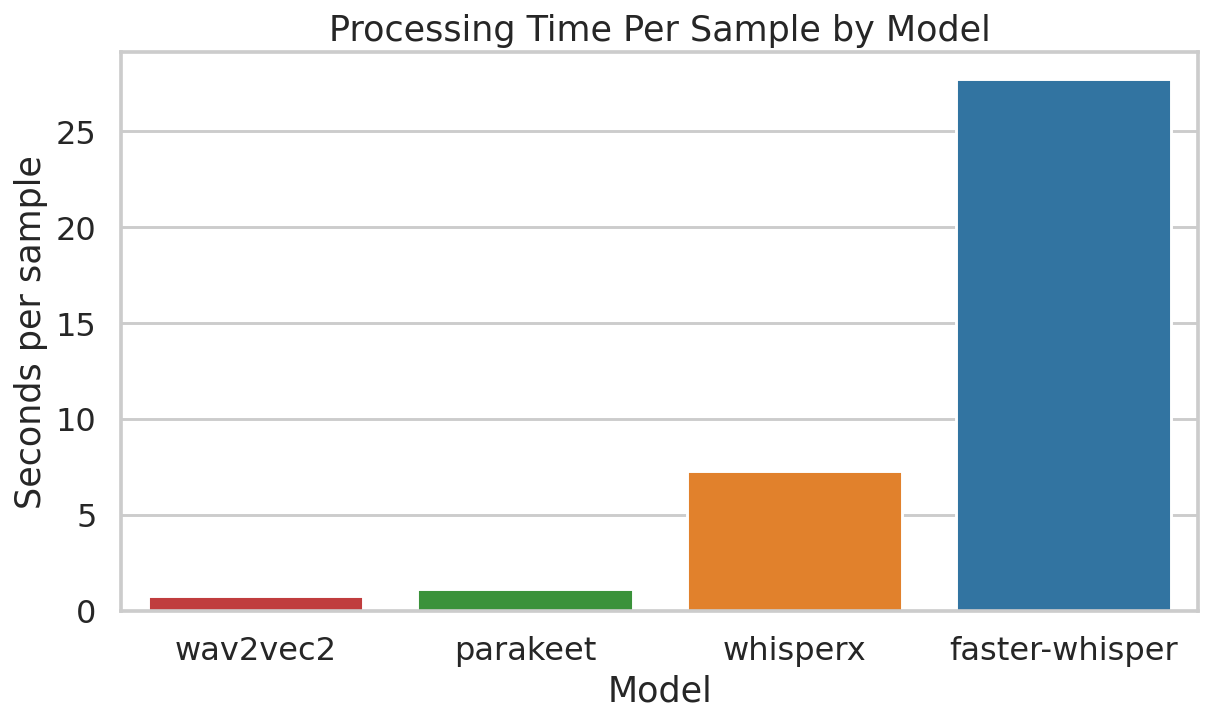

Timing summary (per-sample time + RTF):


,model,time_per_sample_sec,rtf,runs,total_items
2,wav2vec2,0.7541,88.9506,1,100
1,parakeet,1.1243,59.6628,1,100
3,whisperx,7.2756,9.2201,1,100
0,faster-whisper,27.7363,2.4185,1,100


Saved plots to:
- /home/jamin/Year3Proj/Output/plot/snr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/ovr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/clip_by_clip_faster_whisper_vs_whisperx_orc_wer.png
- /home/jamin/Year3Proj/Output/plot/metric_composition_by_model.png
- /home/jamin/Year3Proj/Output/plot/error_distribution_by_model_and_metric_family.png
- /home/jamin/Year3Proj/Output/plot/processing_time_per_sample_by_model.png


: 

In [ ]:
def model_palette(model_names):
    return {model: MODEL_COLORS.get(model, "#333333") for model in model_names}


def plot_metric_vs_condition(data: pd.DataFrame, condition_col: str, title: str, ylabel: str, filename: str) -> None:
    plot_data = data.dropna(subset=[condition_col, "cross_model_error"]).copy()
    plot_data[condition_col] = pd.to_numeric(plot_data[condition_col], errors="coerce")
    plot_data = plot_data.dropna(subset=[condition_col])
    plot_data = plot_data.sort_values(condition_col)

    plt.figure(figsize=(11, 6))
    sns.lineplot(
        data=plot_data,
        x=condition_col,
        y="cross_model_error",
        hue="model",
        hue_order=MODEL_ORDER,
        palette=model_palette(MODEL_ORDER),
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        linewidth=2.2,
    )
    plt.title(title)
    plt.xlabel(condition_col.replace("_", " ").upper())
    plt.ylabel(ylabel)
    plt.legend(title="Model", frameon=True)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=200)
    plt.show()


def add_reference_line(ax):
    low, high = ax.get_xlim()
    ax.plot([low, high], [low, high], linestyle="--", color="#555555", linewidth=1)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)


print("Plot helpers ready")

# Timing report: per-sample processing time + RTF read from timings_100_random.json.
if timings_df.empty:
    print("No timing rows found in timings file.")
else:
    timing_summary = (
        timings_df.groupby("model", as_index=False)
        .agg(
            total_processing_time_sec=("duration_sec", "sum"),
            total_items=("item_count", "sum"),
            runs=("batch_key", "nunique"),
            mean_rtf=("rtf", "mean"),
        )
    )
    timing_summary = timing_summary[timing_summary["total_items"] > 0].copy()
    timing_summary["time_per_sample_sec"] = timing_summary["total_processing_time_sec"] / timing_summary["total_items"]
    timing_summary["rtf"] = timing_summary["mean_rtf"]
    timing_summary = timing_summary.sort_values("time_per_sample_sec", ascending=True)

    plt.figure(figsize=(9, 5.5))
    sns.barplot(
        data=timing_summary,
        x="model",
        y="time_per_sample_sec",
        order=timing_summary["model"],
        hue="model",
        hue_order=timing_summary["model"],
        palette=model_palette(timing_summary["model"]),
        legend=False,
    )
    plt.title("Processing Time Per Sample by Model")
    plt.xlabel("Model")
    plt.ylabel("Seconds per sample")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "processing_time_per_sample_by_model.png", dpi=200)
    plt.show()

    print("Timing summary (per-sample time + RTF):")
    display(
        timing_summary[[
            "model",
            "time_per_sample_sec",
            "rtf",
            "runs",
            "total_items",
        ]].round(4)
    )

print("Saved plots to:")
for plot_name in [
    "snr_vs_mean_error_by_model_mixed_metric.png",
    "ovr_vs_mean_error_by_model_mixed_metric.png",
    "clip_by_clip_faster_whisper_vs_whisperx_orc_wer.png",
    "metric_composition_by_model.png",
    "error_distribution_by_model_and_metric_family.png",
    "processing_time_per_sample_by_model.png",
]:
    print(f"- {PLOTS_DIR / plot_name}")

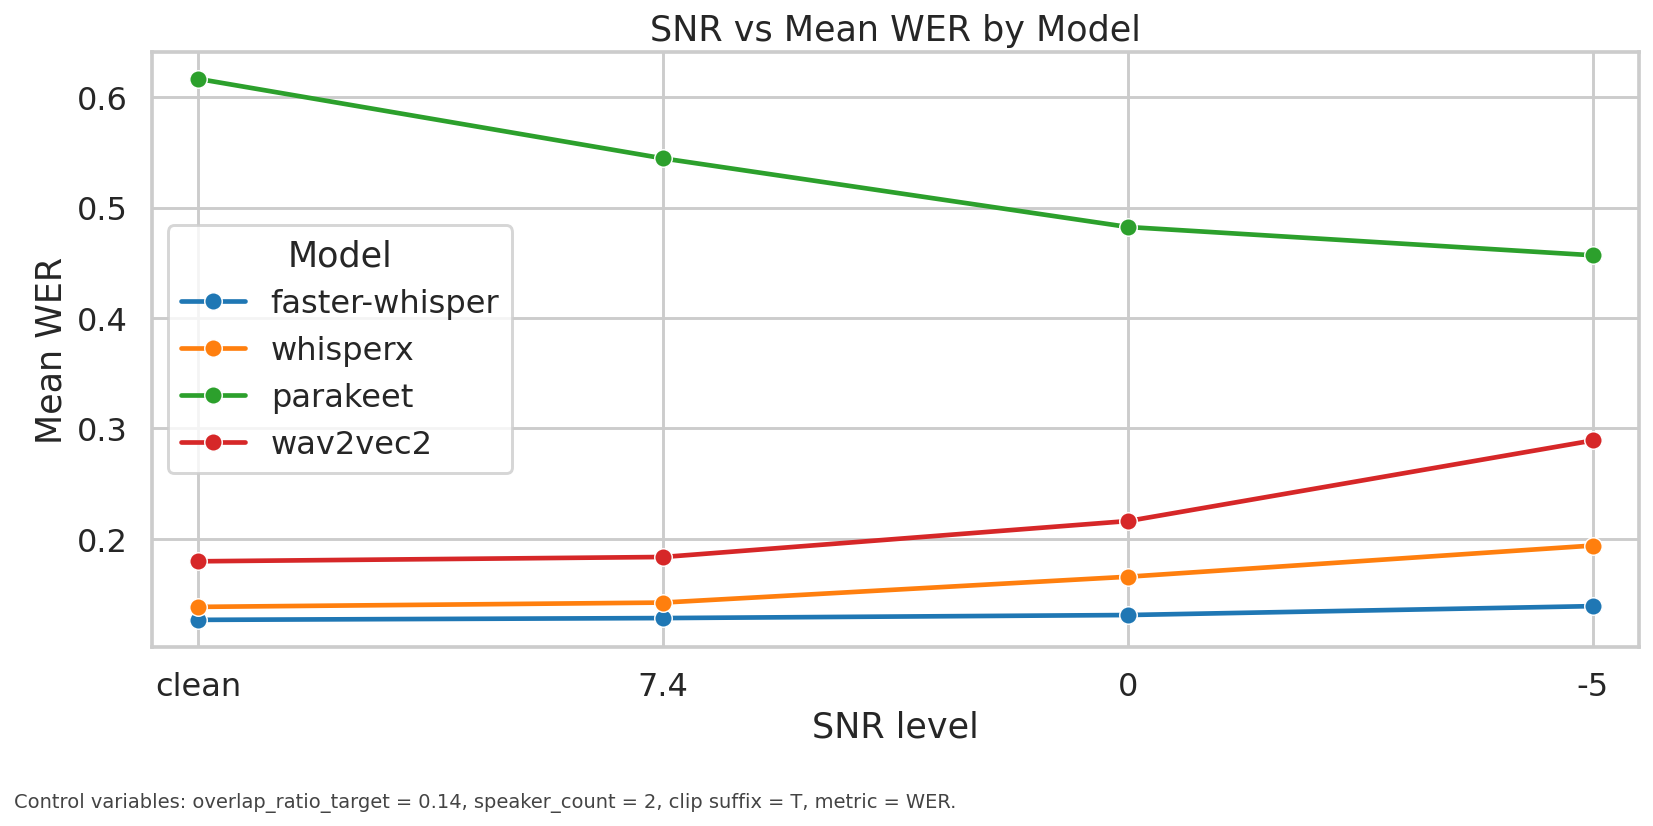

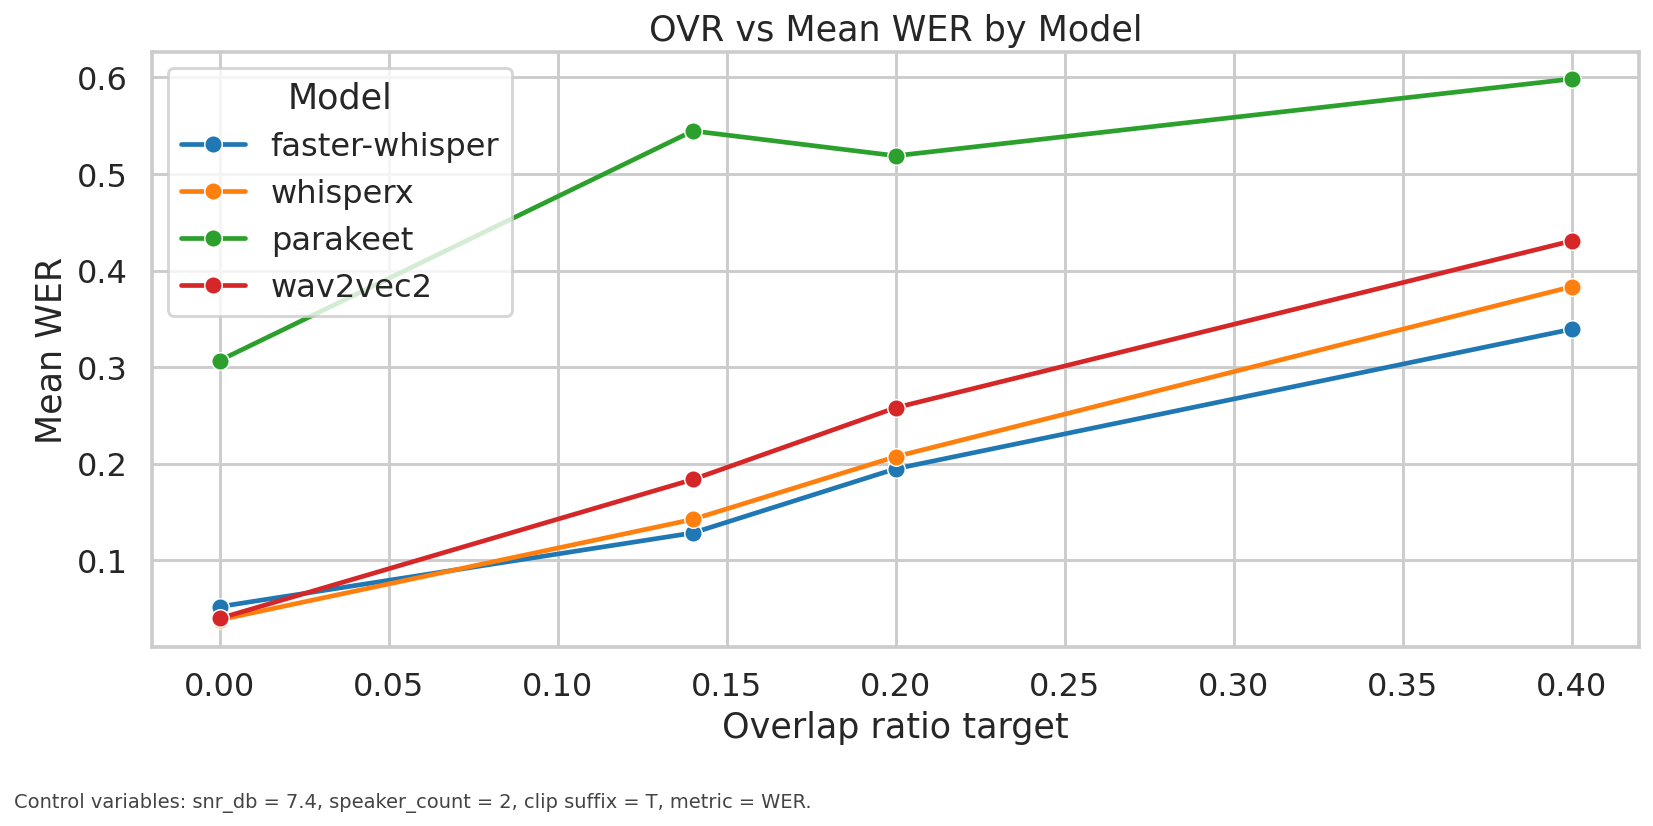

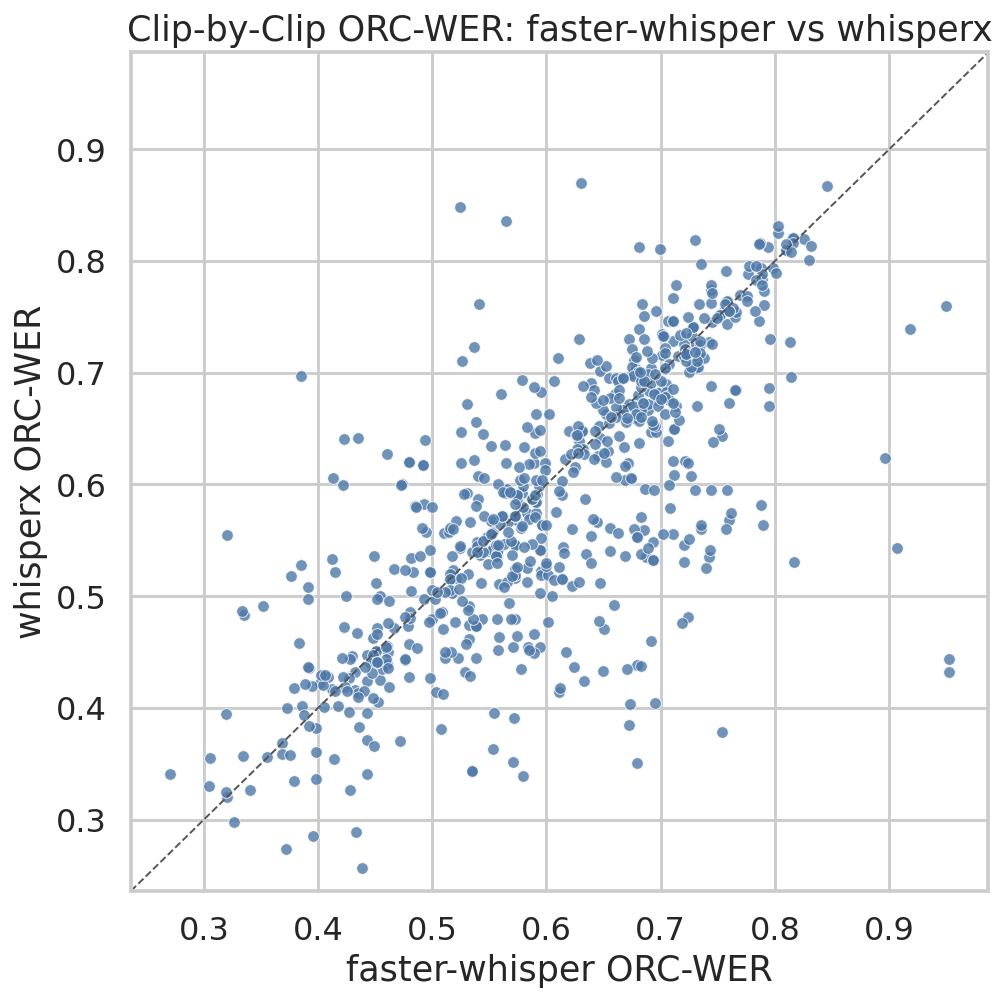

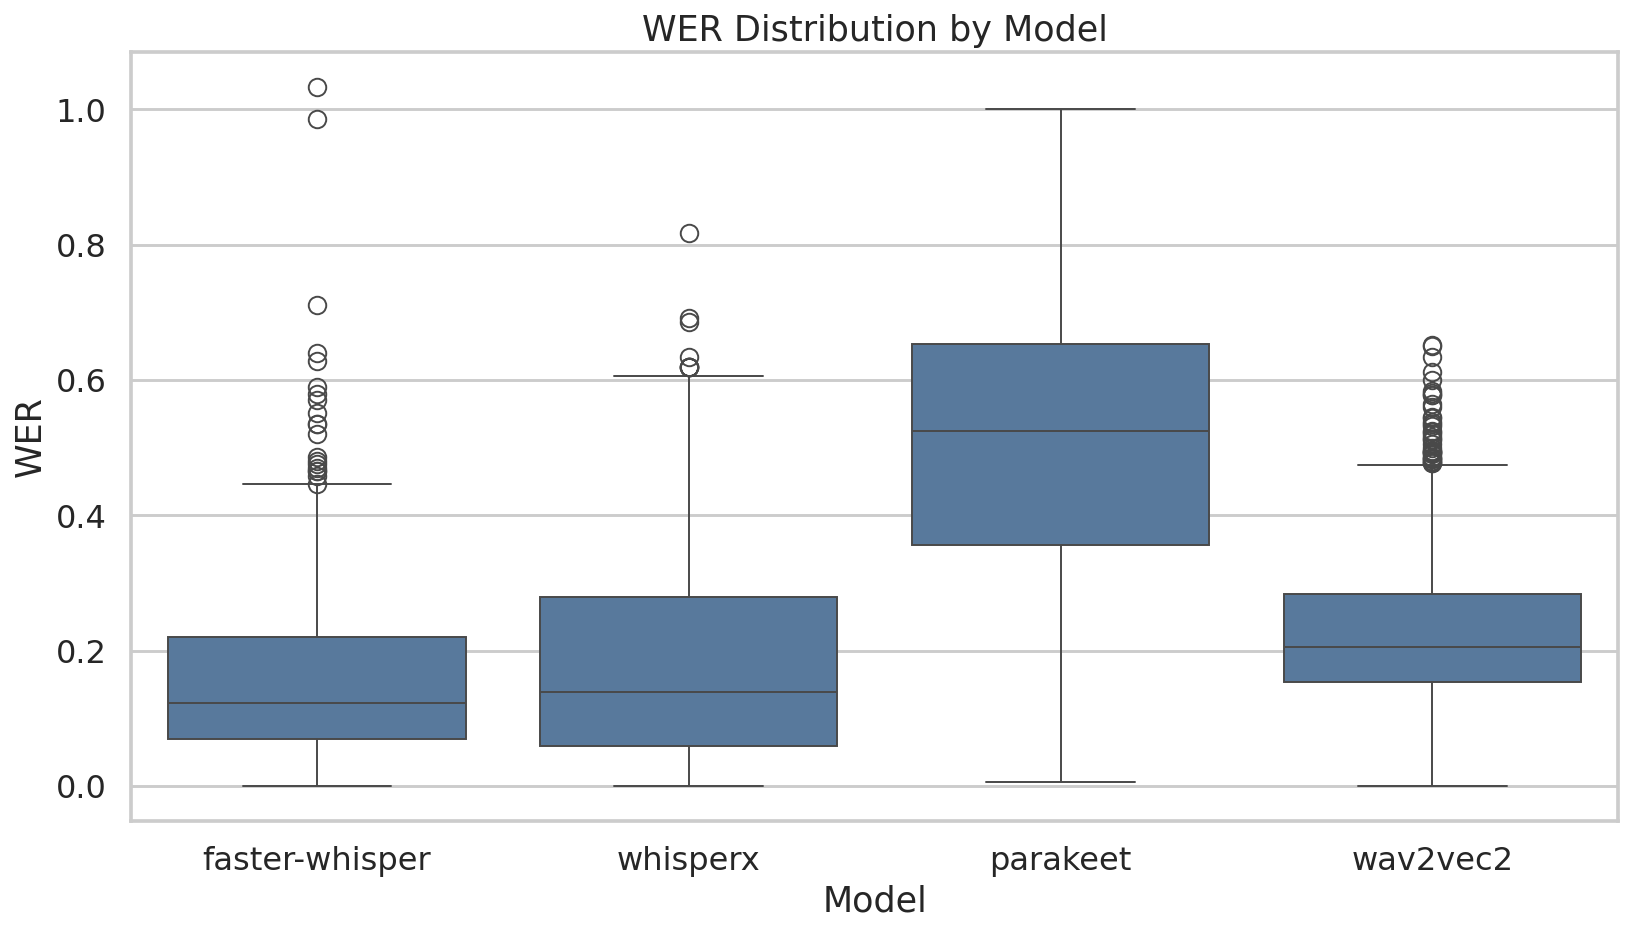

Saved plots to:
- /home/jamin/Year3Proj/Output/plot/snr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/ovr_vs_mean_error_by_model_mixed_metric.png
- /home/jamin/Year3Proj/Output/plot/clip_by_clip_faster_whisper_vs_whisperx_orc_wer.png
- /home/jamin/Year3Proj/Output/plot/error_distribution_by_model_and_metric_family.png


: 

In [ ]:
# SNR vs mean cross-model metric with explicit order: clean, 7.4, 0, -5.
# Controlled setting for this plot: overlap_ratio_target = 0.14 (OVR fixed).
def metric_label(metric_name: str) -> str:
    key = str(metric_name).strip().lower()
    mapping = {
        "wer": "WER",
        "orc_wer": "ORC WER",
        "mrs_wer": "DSS WER",
        "dss_wer": "DSS WER",
    }
    return mapping.get(key, str(metric_name).replace("_", " " ).upper())


metric_names = [
    name
    for name in successful_df["cross_metric_name"].dropna().astype(str).unique().tolist()
]
metric_names = sorted(metric_names)
cross_metric_label = " / ".join(metric_label(name) for name in metric_names) if metric_names else "WER"

snr_order = ["clean", "7.4", "0", "-5"]
snr_pos = {label: idx for idx, label in enumerate(snr_order)}

snr_plot_df = successful_df.dropna(subset=["snr_label", "cross_model_error", "overlap_ratio_target"]).copy()
snr_plot_df["snr_label"] = snr_plot_df["snr_label"].astype(str)
snr_plot_df = snr_plot_df[snr_plot_df["snr_label"].isin(snr_order)]
snr_plot_df = snr_plot_df[np.isclose(snr_plot_df["overlap_ratio_target"].astype(float), 0.14)]

snr_summary = (
    snr_plot_df.groupby(["model", "snr_label"], as_index=False)["cross_model_error"]
    .mean()
)
snr_summary["snr_pos"] = snr_summary["snr_label"].map(snr_pos)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=snr_summary,
    x="snr_pos",
    y="cross_model_error",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=model_palette(MODEL_ORDER),
    marker="o",
    linewidth=2.4,
 )
plt.xticks([0, 1, 2, 3], snr_order)
plt.xlim(-0.1, 3.1)
plt.title(f"SNR vs Mean {cross_metric_label} by Model")
plt.xlabel("SNR level")
plt.ylabel(f"Mean {cross_metric_label}")
plt.legend(title="Model")
snr_caption = f"Control variables: overlap_ratio_target = 0.14, speaker_count = 2, clip suffix = T, metric = {cross_metric_label}."
plt.gcf().text(0.01, 0.01, snr_caption, fontsize=10, color="#444444")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(PLOTS_DIR / "snr_vs_mean_error_by_model_mixed_metric.png", dpi=200)
plt.show()

# OVR vs mean cross-model metric for each model.
# Controlled setting for this plot: snr_db = 7.4 (SNR fixed).
ovr_plot_df = successful_df.dropna(subset=["overlap_ratio_target", "snr_label", "cross_model_error"]).copy()
ovr_plot_df["snr_label"] = ovr_plot_df["snr_label"].astype(str)
ovr_plot_df = ovr_plot_df[ovr_plot_df["snr_label"] == "7.4"]

ovr_summary = (
    ovr_plot_df.groupby(["model", "overlap_ratio_target"], as_index=False)["cross_model_error"]
    .mean()
    .sort_values(["model", "overlap_ratio_target"])
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ovr_summary,
    x="overlap_ratio_target",
    y="cross_model_error",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=model_palette(MODEL_ORDER),
    marker="o",
    linewidth=2.4,
 )
plt.title(f"OVR vs Mean {cross_metric_label} by Model")
plt.xlabel("Overlap ratio target")
plt.ylabel(f"Mean {cross_metric_label}")
plt.legend(title="Model")
ovr_caption = f"Control variables: snr_db = 7.4, speaker_count = 2, clip suffix = T, metric = {cross_metric_label}."
plt.gcf().text(0.01, 0.01, ovr_caption, fontsize=10, color="#444444")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(PLOTS_DIR / "ovr_vs_mean_error_by_model_mixed_metric.png", dpi=200)
plt.show()

# Clip-by-clip comparison between faster-whisper and whisperx using ORC-WER only.
fw_whisperx = (
    results_df.loc[results_df["model"].isin(PAIRWISE_ORC_WER_MODELS) & (results_df["status"] == "success"),
                  ["clip_id", "model", "orc_wer"]]
    .dropna()
    .pivot(index="clip_id", columns="model", values="orc_wer")
    .dropna()
    .reset_index()
)

plt.figure(figsize=(7.5, 7.5))
ax = sns.scatterplot(
    data=fw_whisperx,
    x="faster-whisper",
    y="whisperx",
    s=36,
    alpha=0.8,
    color="#4c78a8",
)
add_reference_line(ax)
plt.title("Clip-by-Clip ORC-WER: faster-whisper vs whisperx")
plt.xlabel("faster-whisper ORC-WER")
plt.ylabel("whisperx ORC-WER")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "clip_by_clip_faster_whisper_vs_whisperx_orc_wer.png", dpi=200)
plt.show()

# Useful interpretation plot 1: this reflects the selected cross-model metric.
metric_mix = (
    successful_df.groupby(["model", "cross_metric_name"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "clips"})
)
metric_pivot = metric_mix.pivot(index="model", columns="cross_metric_name", values="clips").fillna(0)
metric_ratio = metric_pivot.div(metric_pivot.sum(axis=1), axis=0).reset_index()
metric_ratio_long = metric_ratio.melt(id_vars="model", var_name="metric", value_name="ratio")


plt.figure(figsize=(12, 7))
sns.boxplot(
    data=successful_df,
    x="model",
    y="cross_model_error",
    order=MODEL_ORDER,
    color="#4c78a8",
)
plt.title(f"{cross_metric_label} Distribution by Model")
plt.xlabel("Model")
plt.ylabel(cross_metric_label)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "error_distribution_by_model_and_metric_family.png", dpi=200)
plt.show()

print("Saved plots to:")
for plot_name in [
    "snr_vs_mean_error_by_model_mixed_metric.png",
    "ovr_vs_mean_error_by_model_mixed_metric.png",
    "clip_by_clip_faster_whisper_vs_whisperx_orc_wer.png",
    "error_distribution_by_model_and_metric_family.png"
]:
    print(f"- {PLOTS_DIR / plot_name}")

Transferability comparison: synthetic -> real


,model,real_metric,synthetic_metric,real_count,synthetic_total,synthetic_successful,synthetic_success_rate,real_mean,synthetic_mean,gap_real_minus_synth,ratio_real_over_synth,synthetic_rank,real_rank,rank_shift_real_minus_synth
0,parakeet,wer,mrs_wer,100,4800,700,0.1458,0.3886,0.5147,-0.1262,0.7549,4.0,1.0,-3.0
1,wav2vec2,wer,mrs_wer,100,4800,4800,1.0000,0.7228,0.3650,0.3579,1.9805,3.0,2.0,-1.0
2,whisperx,cpwer,mrs_wer,100,4800,700,0.1458,0.8355,0.1788,0.6567,4.6729,2.0,3.0,1.0
3,faster-whisper,cpwer,mrs_wer,100,4800,700,0.1458,0.8949,0.1558,0.7392,5.7453,1.0,4.0,3.0


/tmp/ipykernel_1557/3902894383.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


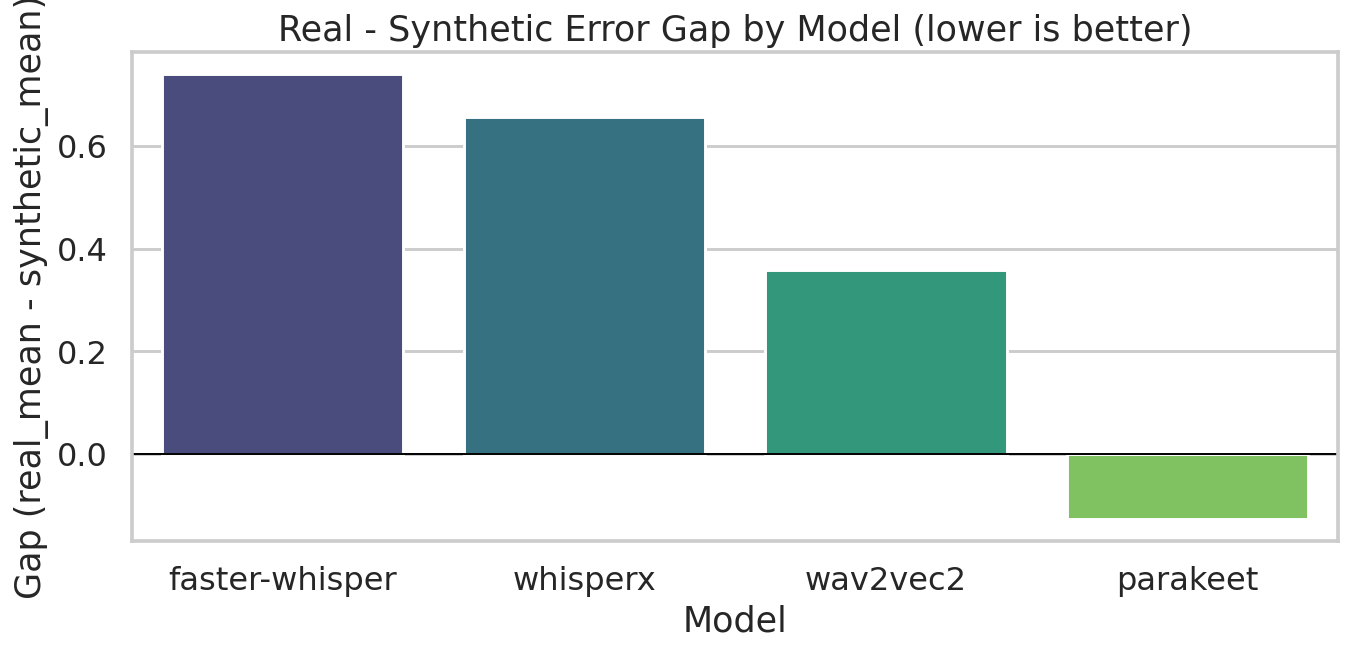

Mean relative degradation (real vs synthetic): 228.84%


In [16]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("/home/jamin/Year3Proj")
REAL_EVAL_PATH = ROOT / "Output" / "real_eval_results.json"
SYN_DIR = ROOT / "WER_Results_by_Model"

with open(REAL_EVAL_PATH, "r", encoding="utf-8") as f:
    real_eval = json.load(f)

# Build real-data stats from per-clip entries so we preserve metric type per model.
real_rows = []
for clip_id, per_model in real_eval.get("by_clip", {}).items():
    for model_name, result in per_model.items():
        real_rows.append(
            {
                "clip_id": clip_id,
                "model": model_name,
                "metric": result.get("metric"),
                "score": result.get("score"),
            }
        )

real_df = pd.DataFrame(real_rows)
if real_df.empty:
    raise RuntimeError("No real-data evaluation rows found in Output/real_eval_results.json")

real_model_summary = (
    real_df.groupby("model")
    .agg(
        real_count=("score", "size"),
        real_mean=("score", "mean"),
        real_median=("score", "median"),
        real_min=("score", "min"),
        real_max=("score", "max"),
    )
    .reset_index()
)

real_metric_mode = (
    real_df.groupby("model")["metric"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index(name="real_metric")
)
real_model_summary = real_model_summary.merge(real_metric_mode, on="model", how="left")


def _pick_synthetic_mean(summary: dict, preferred_metric: str):
    """Pick a synthetic mean metric compatible with real metric for fair transferability comparison."""
    if preferred_metric == "orc_wer":
        if "orc_wer_mean" in summary:
            return "orc_wer", summary["orc_wer_mean"]
        if "mrs_wer_mean" in summary:
            return "mrs_wer", summary["mrs_wer_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
    else:
        if "mrs_wer_mean" in summary:
            return "mrs_wer", summary["mrs_wer_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
        if "orc_wer_mean" in summary:
            return "orc_wer", summary["orc_wer_mean"]

    for key in ("mrs_wer_mean", "wer_mean", "orc_wer_mean"):
        if key in summary:
            return key.replace("_mean", ""), summary[key]
    return None, np.nan


syn_rows = []
for model_file in sorted(SYN_DIR.glob("*_wer_results.json")):
    with open(model_file, "r", encoding="utf-8") as f:
        payload = json.load(f)

    model = payload.get("model")
    summary = payload.get("summary", {})

    # If model is missing in real summary, we still keep synthetic row.
    preferred_metric = (
        real_model_summary.loc[real_model_summary["model"] == model, "real_metric"].iloc[0]
        if model in set(real_model_summary["model"])
        else "mrs_wer"
    )
    syn_metric, syn_mean = _pick_synthetic_mean(summary, preferred_metric)

    syn_rows.append(
        {
            "model": model,
            "synthetic_metric": syn_metric,
            "synthetic_mean": syn_mean,
            "synthetic_total": summary.get("total", np.nan),
            "synthetic_successful": summary.get("successful", np.nan),
            "synthetic_success_rate": (
                (summary.get("successful", 0) / summary.get("total", 1))
                if summary.get("total", 0)
                else np.nan
            ),
        }
    )

syn_df = pd.DataFrame(syn_rows)

transfer_df = real_model_summary.merge(syn_df, on="model", how="outer")
transfer_df["gap_real_minus_synth"] = transfer_df["real_mean"] - transfer_df["synthetic_mean"]
transfer_df["ratio_real_over_synth"] = transfer_df["real_mean"] / transfer_df["synthetic_mean"]

# Lower is better for WER/ORC-WER, so positive gap means degradation on real data.
transfer_df["synthetic_rank"] = transfer_df["synthetic_mean"].rank(method="min")
transfer_df["real_rank"] = transfer_df["real_mean"].rank(method="min")
transfer_df["rank_shift_real_minus_synth"] = transfer_df["real_rank"] - transfer_df["synthetic_rank"]

transfer_df = transfer_df.sort_values("real_mean", ascending=True).reset_index(drop=True)

cols = [
    "model",
    "real_metric",
    "synthetic_metric",
    "real_count",
    "synthetic_total",
    "synthetic_successful",
    "synthetic_success_rate",
    "real_mean",
    "synthetic_mean",
    "gap_real_minus_synth",
    "ratio_real_over_synth",
    "synthetic_rank",
    "real_rank",
    "rank_shift_real_minus_synth",
]

print("Transferability comparison: synthetic -> real")
display(transfer_df[cols].round(4))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=transfer_df.sort_values("gap_real_minus_synth", ascending=False),
    x="model",
    y="gap_real_minus_synth",
    palette="viridis",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Real - Synthetic Error Gap by Model (lower is better)")
plt.ylabel("Gap (real_mean - synthetic_mean)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# Weighted headline figure: average relative degradation across comparable models.
valid = transfer_df.dropna(subset=["ratio_real_over_synth"])
if not valid.empty:
    rel_deg = (valid["ratio_real_over_synth"] - 1.0) * 100.0
    print(f"Mean relative degradation (real vs synthetic): {rel_deg.mean():.2f}%")


Transferability by overlap ratio


,model,ovr_label,clips,real_metric,real_mean,synthetic_mean,gap_real_minus_synth
0,faster-whisper,0.00,100,cpwer,0.8949,0.6187,0.2762
1,faster-whisper,0.14,400,cpwer,0.8949,0.6212,0.2737
2,faster-whisper,0.20,100,cpwer,0.8949,0.5787,0.3162
3,faster-whisper,0.40,100,cpwer,0.8949,0.5450,0.3499
4,parakeet,0.00,100,wer,0.3886,0.5829,-0.1943
5,parakeet,0.14,400,wer,0.3886,0.6463,-0.2578
6,parakeet,0.20,100,wer,0.3886,0.6446,-0.2561
7,parakeet,0.40,100,wer,0.3886,0.6750,-0.2864
8,wav2vec2,0.00,100,wer,0.7228,0.6094,0.1135
9,wav2vec2,0.14,400,wer,0.7228,0.6493,0.0735


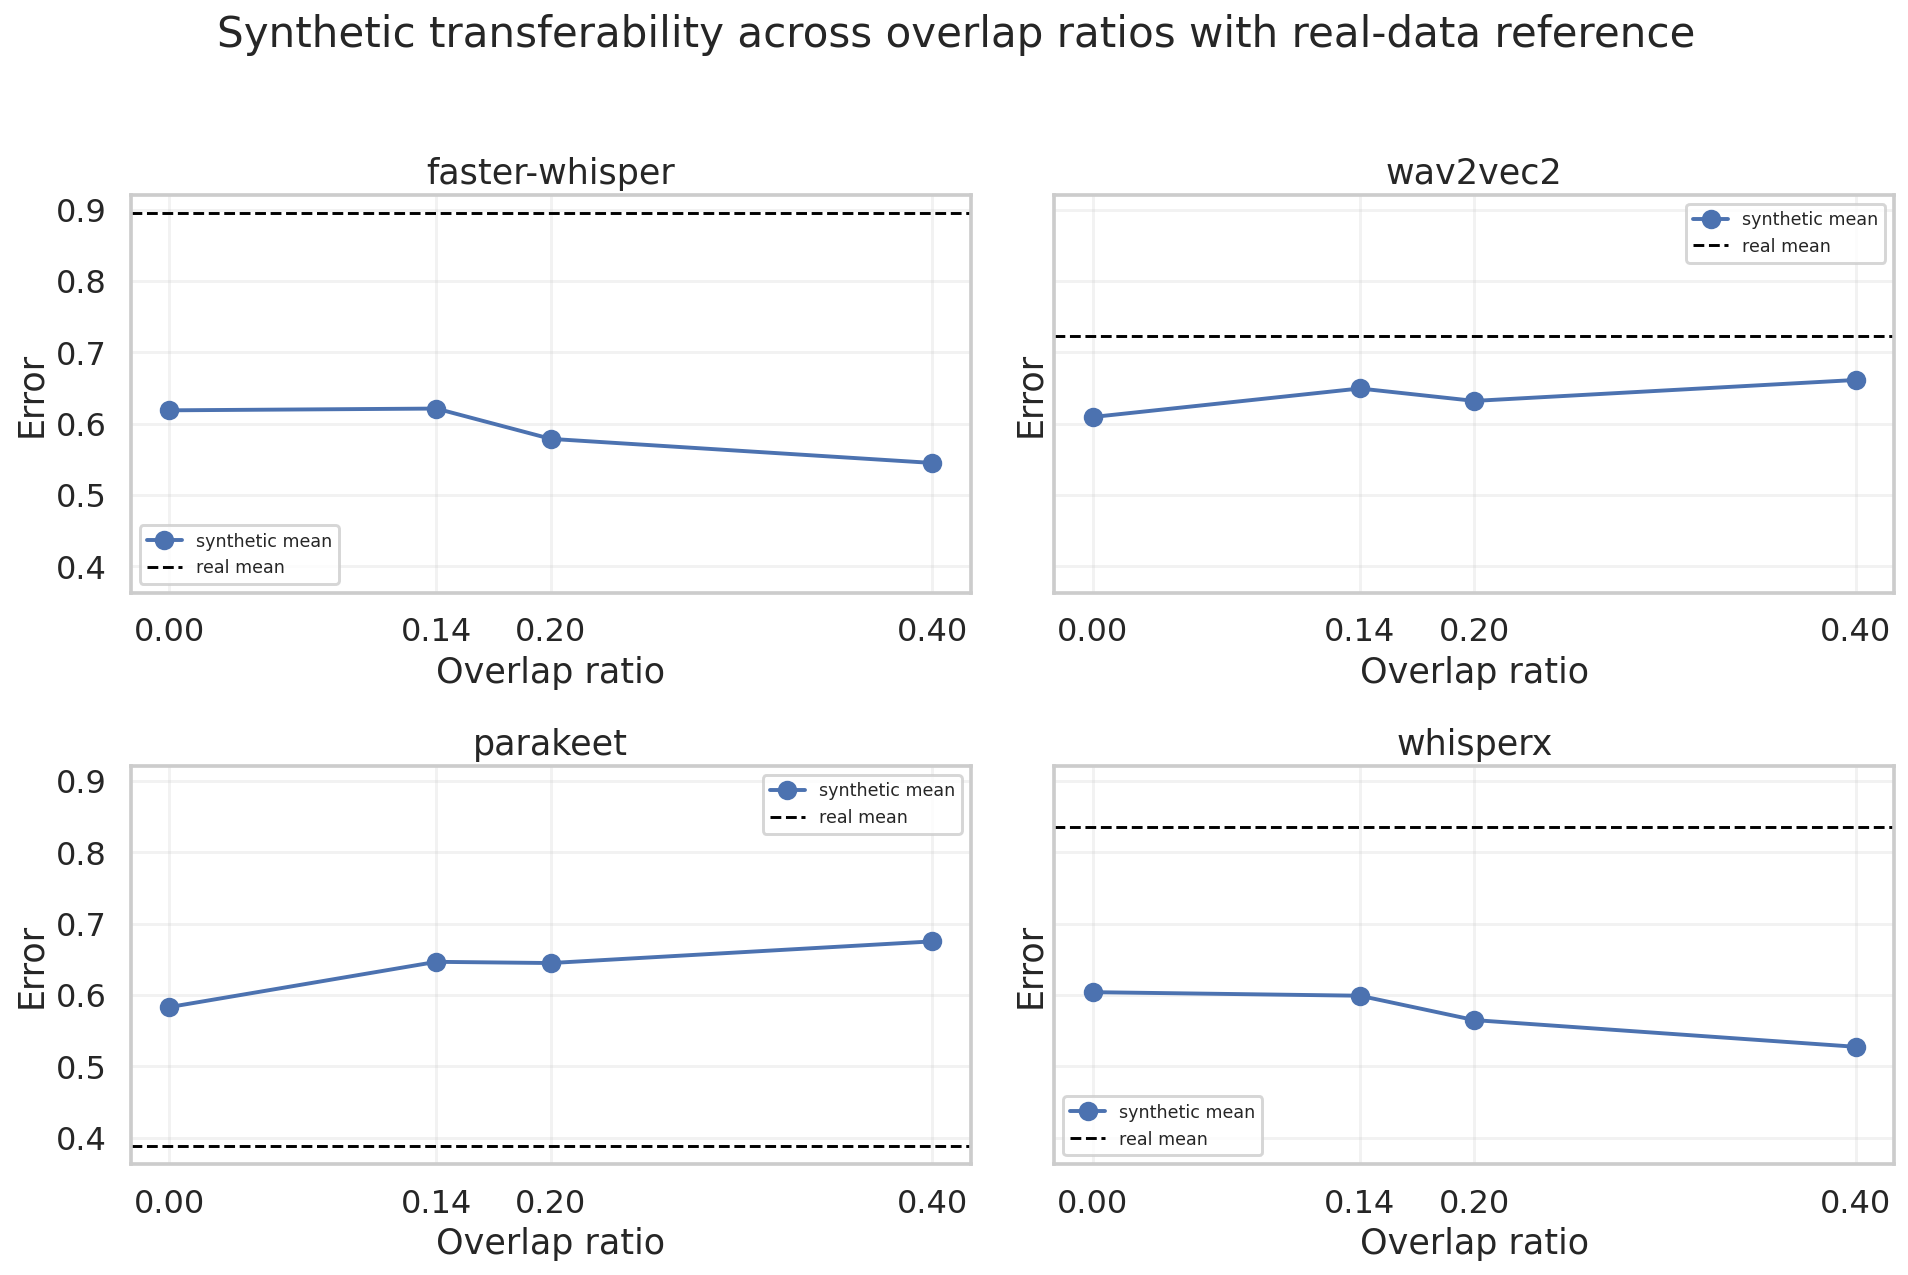

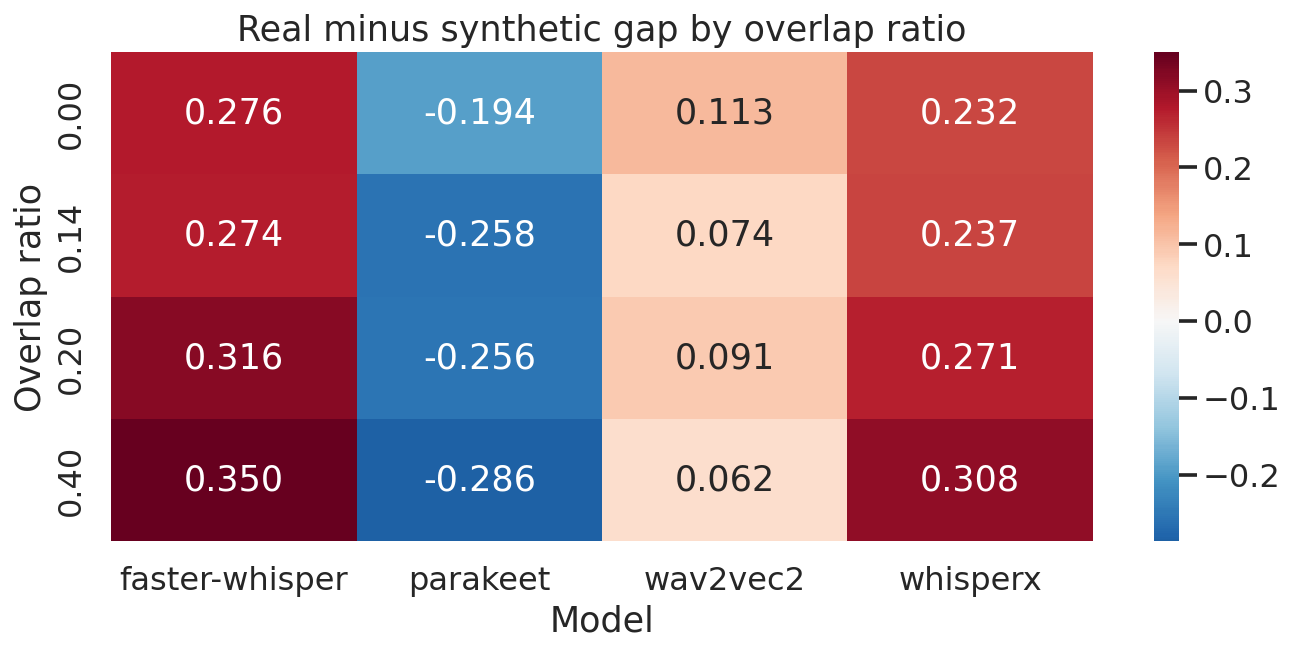

In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("/home/jamin/Year3Proj")
REAL_EVAL_PATH = ROOT / "Output" / "real_eval_results.json"
MANIFEST_PATH = ROOT / "Output" / "manifest.csv"
SYN_DIR = ROOT / "WER_Results_by_Model"
CROSS_MODEL_CLIP_REGEX = r"(^mix_[0-9]+_0\.(00|14|20|40)_2_7\.4_T$)|(^mix_[0-9]+_0\.14_2_(None|7\.4|0|-5)_T$)"


def _pick_mean(summary: dict, preferred_metric: str):
    if preferred_metric == "orc_wer":
        if "orc_wer_mean" in summary:
            return "orc_wer", summary["orc_wer_mean"]
        if "mrs_wer_mean" in summary:
            return "mrs_wer", summary["mrs_wer_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
    else:
        if "mrs_wer_mean" in summary:
            return "mrs_wer", summary["mrs_wer_mean"]
        if "wer_mean" in summary:
            return "wer", summary["wer_mean"]
        if "orc_wer_mean" in summary:
            return "orc_wer", summary["orc_wer_mean"]

    for key in ("mrs_wer_mean", "wer_mean", "orc_wer_mean"):
        if key in summary:
            return key.replace("_mean", ""), summary[key]
    return None, np.nan


def _real_summary_from_eval(real_eval_path: Path) -> pd.DataFrame:
    with open(real_eval_path, "r", encoding="utf-8") as f:
        real_eval = json.load(f)

    rows = []
    for clip_id, per_model in real_eval.get("by_clip", {}).items():
        for model_name, result in per_model.items():
            rows.append(
                {
                    "clip_id": clip_id,
                    "model": model_name,
                    "metric": result.get("metric"),
                    "score": result.get("score"),
                }
            )

    real_df = pd.DataFrame(rows)
    if real_df.empty:
        raise RuntimeError("No rows found in Output/real_eval_results.json")

    real_summary = (
        real_df.groupby("model")
        .agg(
            real_count=("score", "size"),
            real_mean=("score", "mean"),
            real_median=("score", "median"),
        )
        .reset_index()
)
    real_metric_mode = (
        real_df.groupby("model")["metric"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
        .reset_index(name="real_metric")
    )
    return real_summary.merge(real_metric_mode, on="model", how="left")


manifest_df = pd.read_csv(MANIFEST_PATH)
manifest_df = manifest_df[manifest_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
if "overlap_ratio_target" not in manifest_df.columns:
    raise RuntimeError("Manifest is missing overlap_ratio_target; cannot build OVR comparison.")
manifest_df["ovr_label"] = manifest_df["overlap_ratio_target"].map(lambda value: f"{float(value):.2f}" if pd.notna(value) else "unknown")

real_model_summary_ovr = _real_summary_from_eval(REAL_EVAL_PATH)

synthetic_rows = []
for result_path in sorted(SYN_DIR.glob("*_wer_results.json")):
    with open(result_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    model = payload.get("model", result_path.stem.replace("_wer_results", ""))
    summary = payload.get("summary", {})
    preferred_metric = (
        real_model_summary_ovr.loc[real_model_summary_ovr["model"] == model, "real_metric"].iloc[0]
        if model in set(real_model_summary_ovr["model"])
        else "mrs_wer"
    )
    synthetic_metric, synthetic_mean = _pick_mean(summary, preferred_metric)
    synthetic_rows.append(
        {
            "model": model,
            "synthetic_metric": synthetic_metric,
            "synthetic_mean": synthetic_mean,
        }
    )

synthetic_model_summary = pd.DataFrame(synthetic_rows)

# Load the per-clip synthetic results so we can compare across overlap ratios.
clip_rows = []
for result_path in sorted(SYN_DIR.glob("*_wer_results.json")):
    with open(result_path, "r", encoding="utf-8") as f:
        payload = json.load(f)

    model = payload.get("model", result_path.stem.replace("_wer_results", ""))
    for item in payload.get("results", []):
        if item.get("status") != "success":
            continue
        metrics = item.get("metrics", {})
        clip_rows.append(
            {
                "model": model,
                "clip_id": item.get("clip_id"),
                "metric_type": item.get("metric_type"),
                "cross_error": metrics.get("orc_wer") if pd.notna(metrics.get("orc_wer", np.nan)) else metrics.get("mrs_wer"),
                "orc_wer": metrics.get("orc_wer", np.nan),
                "wer": metrics.get("wer", np.nan),
                "mrs_wer": metrics.get("mrs_wer", np.nan),
            }
        )

synthetic_clip_df = pd.DataFrame(clip_rows)
synthetic_clip_df = synthetic_clip_df[synthetic_clip_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
synthetic_clip_df = synthetic_clip_df.merge(manifest_df[["clip_id", "overlap_ratio_target", "ovr_label"]], on="clip_id", how="left")
synthetic_clip_df["synthetic_metric"] = np.where(pd.notna(synthetic_clip_df["orc_wer"]), "orc_wer", "mrs_wer")
synthetic_clip_df["synthetic_error"] = np.where(pd.notna(synthetic_clip_df["orc_wer"]), synthetic_clip_df["orc_wer"], synthetic_clip_df["mrs_wer"])

ovr_compare_df = (
    synthetic_clip_df.groupby(["model", "overlap_ratio_target", "ovr_label"], as_index=False)
    .agg(
        synthetic_mean=("synthetic_error", "mean"),
        clips=("clip_id", "count"),
    )
    .merge(real_model_summary_ovr[["model", "real_mean", "real_metric"]], on="model", how="left")
)
ovr_compare_df["gap_real_minus_synth"] = ovr_compare_df["real_mean"] - ovr_compare_df["synthetic_mean"]
ovr_compare_df = ovr_compare_df.sort_values(["model", "overlap_ratio_target"]).reset_index(drop=True)

print("Transferability by overlap ratio")
display(
    ovr_compare_df[
        ["model", "ovr_label", "clips", "real_metric", "real_mean", "synthetic_mean", "gap_real_minus_synth"]
    ].round(4)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.ravel()
for ax, model in zip(axes, ["faster-whisper", "wav2vec2", "parakeet", "whisperx"]):
    model_df = ovr_compare_df[ovr_compare_df["model"] == model].copy()
    if model_df.empty:
        ax.set_axis_off()
        continue

    x = model_df["overlap_ratio_target"].astype(float)
    ax.plot(x, model_df["synthetic_mean"], marker="o", linewidth=2, label="synthetic mean")
    ax.axhline(model_df["real_mean"].iloc[0], linestyle="--", color="black", linewidth=1.5, label="real mean")
    ax.set_title(model)
    ax.set_xlabel("Overlap ratio")
    ax.set_ylabel("Error")
    ax.set_xticks(sorted(model_df["overlap_ratio_target"].astype(float).unique()))
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)

plt.suptitle("Synthetic transferability across overlap ratios with real-data reference", y=1.02)
plt.tight_layout()
plt.show()

pivot_gap = ovr_compare_df.pivot_table(
    index="ovr_label",
    columns="model",
    values="gap_real_minus_synth",
    aggfunc="mean",
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_gap.sort_index(), annot=True, fmt=".3f", cmap="RdBu_r", center=0)
plt.title("Real minus synthetic gap by overlap ratio")
plt.xlabel("Model")
plt.ylabel("Overlap ratio")
plt.tight_layout()
plt.show()
